In [1]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import pandas as pd

# Load model and tokenizer
model_path = '../models/distilbert_final'

print("Loading model...")
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)

# Set to evaluation mode
model.eval()

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"✅ Model loaded from: {model_path}")
print(f"✅ Using device: {device}")
print(f"✅ Model parameters: {model.num_parameters():,}")

Loading model...
✅ Model loaded from: ../models/distilbert_final
✅ Using device: cpu
✅ Model parameters: 66,955,010


In [2]:
def predict_news(text, return_probabilities=True):
    """
    Predict if news article is FAKE or TRUE
    
    Args:
        text (str): Article text
        return_probabilities (bool): Return probability scores
        
    Returns:
        dict: Prediction results
    """
    # Tokenize
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors='pt'
    )
    
    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
    
    # Format results
    result = {
        'prediction': 'TRUE' if prediction == 1 else 'FAKE',
        'prediction_label': prediction,
        'confidence': probs[0][prediction].item() * 100,
    }
    
    if return_probabilities:
        result['probabilities'] = {
            'fake': probs[0][0].item() * 100,
            'true': probs[0][1].item() * 100
        }
    
    return result

print("✅ Prediction function created!")

✅ Prediction function created!


In [3]:
# Test Article 1: Known FAKE news style
fake_article = """
BREAKING: Scientists Discover That Eating Chocolate Every Day 
Makes You Live Forever! Doctors Hate This One Simple Trick!

A new study from the University of Nowhere has found that eating 
5 pounds of chocolate daily will extend your life by 200 years. 
Big Pharma doesn't want you to know this secret! Share this before 
they delete it!
"""

# Test Article 2: Known TRUE news style
true_article = """
WASHINGTON (Reuters) - The Federal Reserve announced today that 
interest rates will remain unchanged at current levels. The decision 
comes after careful analysis of economic indicators including inflation 
rates and employment data. Federal Reserve Chairman stated that the 
committee will continue to monitor economic conditions closely and 
make adjustments as necessary to maintain economic stability.
"""

print("="*60)
print("TEST 1: FAKE NEWS STYLE ARTICLE")
print("="*60)
print(f"Article: {fake_article[:200]}...\n")
result1 = predict_news(fake_article)
print(f"Prediction: {result1['prediction']}")
print(f"Confidence: {result1['confidence']:.2f}%")
print(f"Probabilities:")
print(f"  Fake: {result1['probabilities']['fake']:.2f}%")
print(f"  True: {result1['probabilities']['true']:.2f}%")

print("\n" + "="*60)
print("TEST 2: TRUE NEWS STYLE ARTICLE")
print("="*60)
print(f"Article: {true_article[:200]}...\n")
result2 = predict_news(true_article)
print(f"Prediction: {result2['prediction']}")
print(f"Confidence: {result2['confidence']:.2f}%")
print(f"Probabilities:")
print(f"  Fake: {result2['probabilities']['fake']:.2f}%")
print(f"  True: {result2['probabilities']['true']:.2f}%")

TEST 1: FAKE NEWS STYLE ARTICLE
Article: 
BREAKING: Scientists Discover That Eating Chocolate Every Day 
Makes You Live Forever! Doctors Hate This One Simple Trick!

A new study from the University of Nowhere has found that eating 
5 pounds ...

Prediction: FAKE
Confidence: 99.99%
Probabilities:
  Fake: 99.99%
  True: 0.01%

TEST 2: TRUE NEWS STYLE ARTICLE
Article: 
WASHINGTON (Reuters) - The Federal Reserve announced today that 
interest rates will remain unchanged at current levels. The decision 
comes after careful analysis of economic indicators including in...

Prediction: TRUE
Confidence: 100.00%
Probabilities:
  Fake: 0.00%
  True: 100.00%


In [4]:
# Load your test data
df = pd.read_csv('../data/processed/cleaned_news_data.csv')

# Get some random samples
import random
random.seed(42)

# Get 5 fake and 5 true articles
fake_samples = df[df['label'] == 0].sample(5)
true_samples = df[df['label'] == 1].sample(5)

print("="*60)
print("TESTING ON REAL DATASET SAMPLES")
print("="*60)

correct_predictions = 0
total_predictions = 0

print("\n📰 FAKE NEWS SAMPLES:\n")
for idx, row in fake_samples.iterrows():
    text = row['text']
    actual = 'FAKE'
    
    result = predict_news(text)
    predicted = result['prediction']
    confidence = result['confidence']
    
    is_correct = (predicted == actual)
    correct_predictions += is_correct
    total_predictions += 1
    
    status = "✅" if is_correct else "❌"
    print(f"{status} Title: {row['title'][:60]}...")
    print(f"   Predicted: {predicted} ({confidence:.1f}% confidence)")
    print()

print("\n📰 TRUE NEWS SAMPLES:\n")
for idx, row in true_samples.iterrows():
    text = row['text']
    actual = 'TRUE'
    
    result = predict_news(text)
    predicted = result['prediction']
    confidence = result['confidence']
    
    is_correct = (predicted == actual)
    correct_predictions += is_correct
    total_predictions += 1
    
    status = "✅" if is_correct else "❌"
    print(f"{status} Title: {row['title'][:60]}...")
    print(f"   Predicted: {predicted} ({confidence:.1f}% confidence)")
    print()

print("="*60)
print(f"Accuracy on samples: {correct_predictions}/{total_predictions} ({correct_predictions/total_predictions*100:.1f}%)")
print("="*60)

TESTING ON REAL DATASET SAMPLES

📰 FAKE NEWS SAMPLES:

✅ Title:  D’oh!: Trump Tells Crowd In Richest County In America Its E...
   Predicted: FAKE (100.0% confidence)

✅ Title:  GOP Senator Boldly Defies McConnell, Vows To Be The One To ...
   Predicted: FAKE (100.0% confidence)

✅ Title:  WATCH: ‘House’ Actor Hugh Laurie BURNS Trump During His Gol...
   Predicted: FAKE (100.0% confidence)

✅ Title: HILLARY’S NEW AMERICA: Uniformed Police Officers NOT ALLOWED...
   Predicted: FAKE (100.0% confidence)

✅ Title: PANERA BREAD CEO 2014: “Don’t Bring Your Guns Into Restauran...
   Predicted: FAKE (100.0% confidence)


📰 TRUE NEWS SAMPLES:

✅ Title: Senate panel votes to advance tax bill...
   Predicted: TRUE (100.0% confidence)

✅ Title: NRA opposes outright U.S. ban on gun devices used by Las Veg...
   Predicted: TRUE (100.0% confidence)

✅ Title: Australia police arrest man accused of plotting NYE attack i...
   Predicted: TRUE (100.0% confidence)

✅ Title: UK raises 'grave concerns' abou

Testing on 100 random articles...
BATCH TEST RESULTS (100 articles)

Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        42
        True       1.00      1.00      1.00        58

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



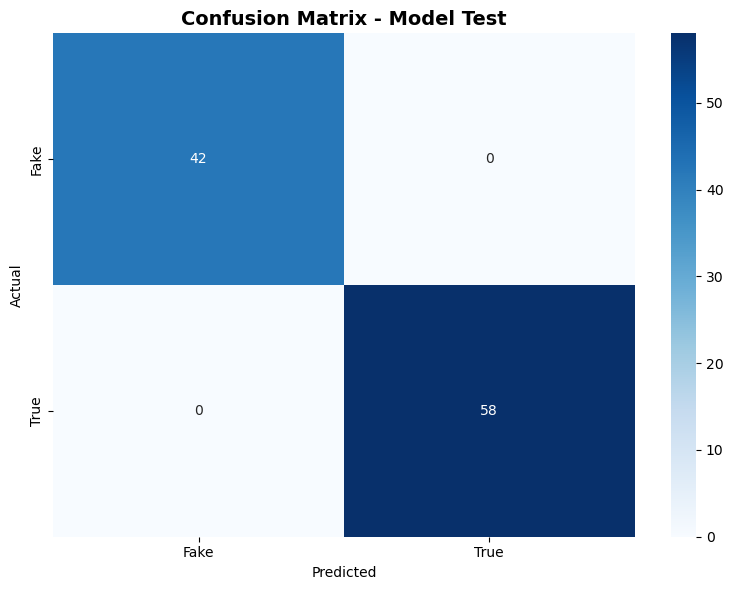


✅ Model is working correctly!


In [6]:
# Test on larger batch
print("Testing on 100 random articles...")

test_sample = df.sample(100, random_state=42)
predictions = []
actuals = []

for idx, row in test_sample.iterrows():
    result = predict_news(row['text'])
    predictions.append(1 if result['prediction'] == 'TRUE' else 0)
    actuals.append(row['label'])

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(actuals, predictions)

print("="*60)
print("BATCH TEST RESULTS (100 articles)")
print("="*60)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(actuals, predictions, target_names=['Fake', 'True']))

# Confusion Matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'])
plt.title('Confusion Matrix - Model Test', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\n✅ Model is working correctly!")

In [32]:
def test_custom_article():
    """
    Interactive function to test your own articles
    """
    print("="*60)
    print("CUSTOM ARTICLE TESTING")
    print("="*60)
    print("Paste an article (or type 'quit' to exit):\n")
    
    article = input()
    
    if article.lower() == 'quit':
        return
    
    result = predict_news(article)
    
    print("\n" + "="*60)
    print("YOUR ARTICLE")
    print("="*60)
    print(article)
    
    print("\n" + "="*60)
    print("PREDICTION RESULT")
    print("="*60)
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print(f"\nProbability Breakdown:")
    print(f"  Fake News: {result['probabilities']['fake']:.2f}%")
    print(f"  True News: {result['probabilities']['true']:.2f}%")
    print("="*60)

# Run interactive test
test_custom_article()

CUSTOM ARTICLE TESTING
Paste an article (or type 'quit' to exit):


YOUR ARTICLE
BREAKING: Hillary Clinton Caught Red-Handed! Secret Documents Prove She's Been Working with Russia All Along! The Deep State Media Won't Report This! Anonymous FBI Sources Confirm Everything! Share Before They Delete This!

PREDICTION RESULT
Prediction: FAKE
Confidence: 99.99%

Probability Breakdown:
  Fake News: 99.99%
  True News: 0.01%
